In [1]:
from pathlib import Path

import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LinearSegmentedColormap, Normalize, TwoSlopeNorm, SymLogNorm


In [2]:
MAJOR_GROUP_COLORS = {
    "Isocortex": "#4DB6AC",
    "OLF": "#4F81BD",
    "HPF": "#7FBF7B",
    "CTXsp": "#E57373",
    "STR": "#B39DDB",
    "PAL": "#D4A15A",
    "HY": "#AED581",
    "TH": "#7986CB",
    "MB": "#F48FB1",
}

class PositiveBoostNorm(Normalize):
    def __init__(self, vmin: float, vmax: float, pos_gamma: float = 0.35, clip: bool = False):
        super().__init__(vmin=vmin, vmax=vmax, clip=clip)
        self.pos_gamma = pos_gamma

    def __call__(self, value, clip=None):
        result, is_scalar = self.process_value(value)
        data = np.asarray(result.data, dtype=float)
        if clip or self.clip:
            data = np.clip(data, self.vmin, self.vmax)

        out = np.empty_like(data, dtype=float)
        neg = data < 0
        pos = ~neg

        out[neg] = 0.5 * ((data[neg] - self.vmin) / (0.0 - self.vmin))
        pos_scaled = np.clip(data[pos] / self.vmax, 0.0, 1.0)
        out[pos] = 0.5 + 0.5 * np.power(pos_scaled, self.pos_gamma)

        masked = np.ma.array(out, mask=np.ma.getmask(result))
        if is_scalar:
            return masked[0]
        return masked
    
class CustomNorm(Normalize):
    def __init__(self, vmin: float, vmax: float, eps: float = 1e-3, clip: bool = False):
        super().__init__(vmin=vmin, vmax=vmax, clip=clip)
        self.eps = eps
    
    def __call__(self, value, clip=None):
        result, is_scalar = self.process_value(value)
        data = np.asarray(result.data, dtype=float)
        if clip or self.clip:
            data = np.clip(data, self.vmin, self.vmax)
        out = np.empty_like(data, dtype=float)    
        neg = data < 0
        pos_eps = np.logical_and(data >=0, data <= self.eps)
        pos = data > self.eps
        
        out[neg] = 0.5 * ((data[neg] - self.vmin) / (0.0 - self.vmin))
        out[pos_eps] = 0.5
        out[pos] = np.log(data[pos] + 1 - self.eps) + 0.5
        
        return out


def build_cmap(name: str):
    if name == "tapeanalyzer":
        return LinearSegmentedColormap.from_list("custom_rwb", ["#9bbdde", "#FFFFFF", "#ce6b6b"])
    if name == "jet":
        return plt.get_cmap("jet")
    raise ValueError(f"Unsupported cmap: {name}")


def build_norm(norm, **kwargs) -> Normalize:
    if norm == "linear":
        return TwoSlopeNorm(vmin=kwargs['vmin'], vcenter=0.0, vmax=kwargs['vmax'])
    if norm == "positive_boost":
        return PositiveBoostNorm(vmin=kwargs['vmin'], vmax=kwargs['vmax'], pos_gamma=kwargs['pos_gamma'])
    if norm == "log":
        return SymLogNorm(kwargs['linthresh'], linscale=0.01, vmin=kwargs['vmin'], vmax=kwargs['vmax'], clip=False)
    if norm == "custom":
        return CustomNorm(kwargs['vmin'], kwargs['vmax'])
    raise ValueError(f"Unsupported norm: {norm}")

In [3]:
def sort_data_median_corr(data):
    median_data = np.median(data, axis=0, keepdims=True)
    corr = np.matmul(data, median_data.T)
    corr = np.squeeze(corr)
    norm = np.sqrt(np.mean(data ** 2, axis=1))
    norm_median = np.sqrt(np.mean(median_data ** 2))
    corr = corr / (norm * norm_median)
    order = np.argsort(-corr)
    data = data[order, :]
    return data

def sort_data_median_dist(data):
    median_data = np.median(data, axis=0, keepdims=True)
    dist = np.mean((data - median_data) ** 2, axis=1)
    order = np.argsort(dist)
    data = data[order, :]
    return data

def sort_data_weight_center(data):
    idx = np.arange(data.shape[1])
    cow = np.sum(idx * data, axis=1) / np.sum(data, axis=1)
    order = np.argsort(cow)
    data = data[order, :]
    return data

In [4]:
BUNDLE_DIR = Path("../outputs/reports/brainwide_region_overlays/20260505_brainwide_random_forest_label_csv_bundles")
SUMMARY_CSV = BUNDLE_DIR / "summary.csv"

# Set to None for full-resolution/full-row plots. For quick notebook iteration, use a cap.
# no_response is now ~98k rows and ~1.9GB, so capped chunk loading is the safer default.
MAX_ROWS_PER_CLASS = 5000
CHUNKSIZE = 20000

def load_trace_matrix(matrix_csv: Path, max_rows: int | None = None) -> pd.DataFrame:
    if max_rows is None:
        return pd.read_csv(matrix_csv)
    meta = pd.read_csv(matrix_csv, usecols=["major_group"])
    if len(meta) <= max_rows:
        return pd.read_csv(matrix_csv)
    counts = meta["major_group"].value_counts(sort=False)
    quotas = (counts / counts.sum() * max_rows).round().astype(int).clip(lower=1)
    while quotas.sum() > max_rows:
        largest = quotas.idxmax()
        quotas.loc[largest] -= 1
    while quotas.sum() < max_rows:
        largest = counts.idxmax()
        quotas.loc[largest] += 1
    taken = {k: 0 for k in quotas.index}
    pieces = []
    rng = np.random.default_rng(0)
    for chunk in pd.read_csv(matrix_csv, chunksize=CHUNKSIZE):
        for group, quota in quotas.items():
            remaining = int(quota - taken[group])
            if remaining <= 0:
                continue
            sub = chunk.loc[chunk["major_group"] == group]
            if sub.empty:
                continue
            n = min(remaining, len(sub))
            pieces.append(sub.sample(n=n, random_state=int(rng.integers(0, 1_000_000))))
            taken[group] += n
        if all(taken[group] >= quotas.loc[group] for group in quotas.index):
            break
    return pd.concat(pieces, ignore_index=True) if pieces else pd.DataFrame()

summary_df = pd.read_csv(SUMMARY_CSV)
names = summary_df["label"].tolist()
print(summary_df)

heatmaps = {}
major_dfs = {}

for cls_name in names:
    class_dir = BUNDLE_DIR / cls_name
    matrix_csv = class_dir / f"{cls_name}_trace_matrix.csv"
    df = load_trace_matrix(matrix_csv, MAX_ROWS_PER_CLASS)
    df = df.sort_values(["major_group", "region", "prediction_confidence"], ascending=[True, True, False]).reset_index(drop=True)
    raw_cols = [c for c in df.columns if c.startswith("raw_")]
    # In this bundle raw_ columns are already baseline-subtracted shifted traces.
    heatmaps[cls_name] = df[raw_cols].to_numpy(dtype=float)
    major_dfs[cls_name] = (
        df.groupby("major_group", sort=False)
        .size()
        .reset_index(name="n_rows")
        .assign(row_start=lambda x: x["n_rows"].cumsum().shift(fill_value=0),
                row_end=lambda x: x["n_rows"].cumsum() - 1)
    )
    print(cls_name, df.shape)


                label                                             folder  \
0         no_response  outputs/reports/brainwide_region_overlays/2026...   
1          inhibition  outputs/reports/brainwide_region_overlays/2026...   
2     weak_first_peak  outputs/reports/brainwide_region_overlays/2026...   
3   strong_first_peak  outputs/reports/brainwide_region_overlays/2026...   
4  sustained_response  outputs/reports/brainwide_region_overlays/2026...   
5           dual_peak  outputs/reports/brainwide_region_overlays/2026...   
6         second_peak  outputs/reports/brainwide_region_overlays/2026...   
7             complex  outputs/reports/brainwide_region_overlays/2026...   

   n_predicted_label  
0              98017  
1              37505  
2              15578  
3              30056  
4              36715  
5                422  
6                299  
7               1111  
no_response (5000, 1009)
inhibition (5000, 1009)
weak_first_peak (5000, 1009)
strong_first_peak (5000, 1009)

In [5]:
area_names = ["CTXsp", "HPF", "HY", "Isocortex", "OLF", "PAL", "STR", "TH"]
boundaries = {}

for cls_name in names:
    major_df = major_dfs[cls_name]
    heatmap = heatmaps[cls_name]
    data_dict = {}
    print(cls_name, heatmap.shape)
    for _, row in major_df.iterrows():
        row_start, row_end = int(row["row_start"]), int(row["row_end"])
        subdata = heatmap[row_start:row_end + 1, :]
        if len(subdata):
            subdata = sort_data_weight_center(subdata)
        data_dict[row["major_group"]] = subdata

    hm = []
    boundary = []
    idx = 0
    for an in area_names:
        if an not in data_dict or len(data_dict[an]) == 0:
            continue
        hm.append(data_dict[an])
        next_idx = idx + data_dict[an].shape[0] - 1
        boundary.append((an, idx, next_idx))
        idx = next_idx + 1
    heatmaps[cls_name] = np.concatenate(hm, axis=0) if hm else np.empty((0, 1000))
    boundaries[cls_name] = boundary
    print(cls_name, heatmaps[cls_name].shape, boundary)


no_response (5000, 1000)
no_response (4996, 1000) [('CTXsp', 0, 204), ('HPF', 205, 811), ('HY', 812, 1282), ('Isocortex', 1283, 2937), ('OLF', 2938, 3284), ('PAL', 3285, 3465), ('STR', 3466, 4420), ('TH', 4421, 4995)]
inhibition (5000, 1000)
inhibition (4998, 1000) [('CTXsp', 0, 219), ('HPF', 220, 892), ('HY', 893, 1416), ('Isocortex', 1417, 3181), ('OLF', 3182, 3493), ('PAL', 3494, 3671), ('STR', 3672, 4311), ('TH', 4312, 4997)]
weak_first_peak (5000, 1000)
weak_first_peak (4998, 1000) [('CTXsp', 0, 210), ('HPF', 211, 927), ('HY', 928, 1447), ('Isocortex', 1448, 3213), ('OLF', 3214, 3571), ('PAL', 3572, 3737), ('STR', 3738, 4440), ('TH', 4441, 4997)]
strong_first_peak (5000, 1000)
strong_first_peak (4998, 1000) [('CTXsp', 0, 211), ('HPF', 212, 987), ('HY', 988, 1416), ('Isocortex', 1417, 3240), ('OLF', 3241, 3581), ('PAL', 3582, 3711), ('STR', 3712, 4429), ('TH', 4430, 4997)]
sustained_response (5000, 1000)
sustained_response (4999, 1000) [('CTXsp', 0, 217), ('HPF', 218, 1010), ('HY',

In [6]:
print(boundaries)

{'no_response': [('CTXsp', 0, 204), ('HPF', 205, 811), ('HY', 812, 1282), ('Isocortex', 1283, 2937), ('OLF', 2938, 3284), ('PAL', 3285, 3465), ('STR', 3466, 4420), ('TH', 4421, 4995)], 'inhibition': [('CTXsp', 0, 219), ('HPF', 220, 892), ('HY', 893, 1416), ('Isocortex', 1417, 3181), ('OLF', 3182, 3493), ('PAL', 3494, 3671), ('STR', 3672, 4311), ('TH', 4312, 4997)], 'weak_first_peak': [('CTXsp', 0, 210), ('HPF', 211, 927), ('HY', 928, 1447), ('Isocortex', 1448, 3213), ('OLF', 3214, 3571), ('PAL', 3572, 3737), ('STR', 3738, 4440), ('TH', 4441, 4997)], 'strong_first_peak': [('CTXsp', 0, 211), ('HPF', 212, 987), ('HY', 988, 1416), ('Isocortex', 1417, 3240), ('OLF', 3241, 3581), ('PAL', 3582, 3711), ('STR', 3712, 4429), ('TH', 4430, 4997)], 'sustained_response': [('CTXsp', 0, 217), ('HPF', 218, 1010), ('HY', 1011, 1308), ('Isocortex', 1309, 3305), ('OLF', 3306, 3649), ('PAL', 3650, 3758), ('STR', 3759, 4550), ('TH', 4551, 4998)], 'dual_peak': [('CTXsp', 0, 10), ('HPF', 11, 72), ('HY', 73, 8

/var/folders/bw/h94700p51374zgrbzwg8hrbh0000gn/T/ipykernel_29759/3274620167.py:7: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.92, wspace=0.3)


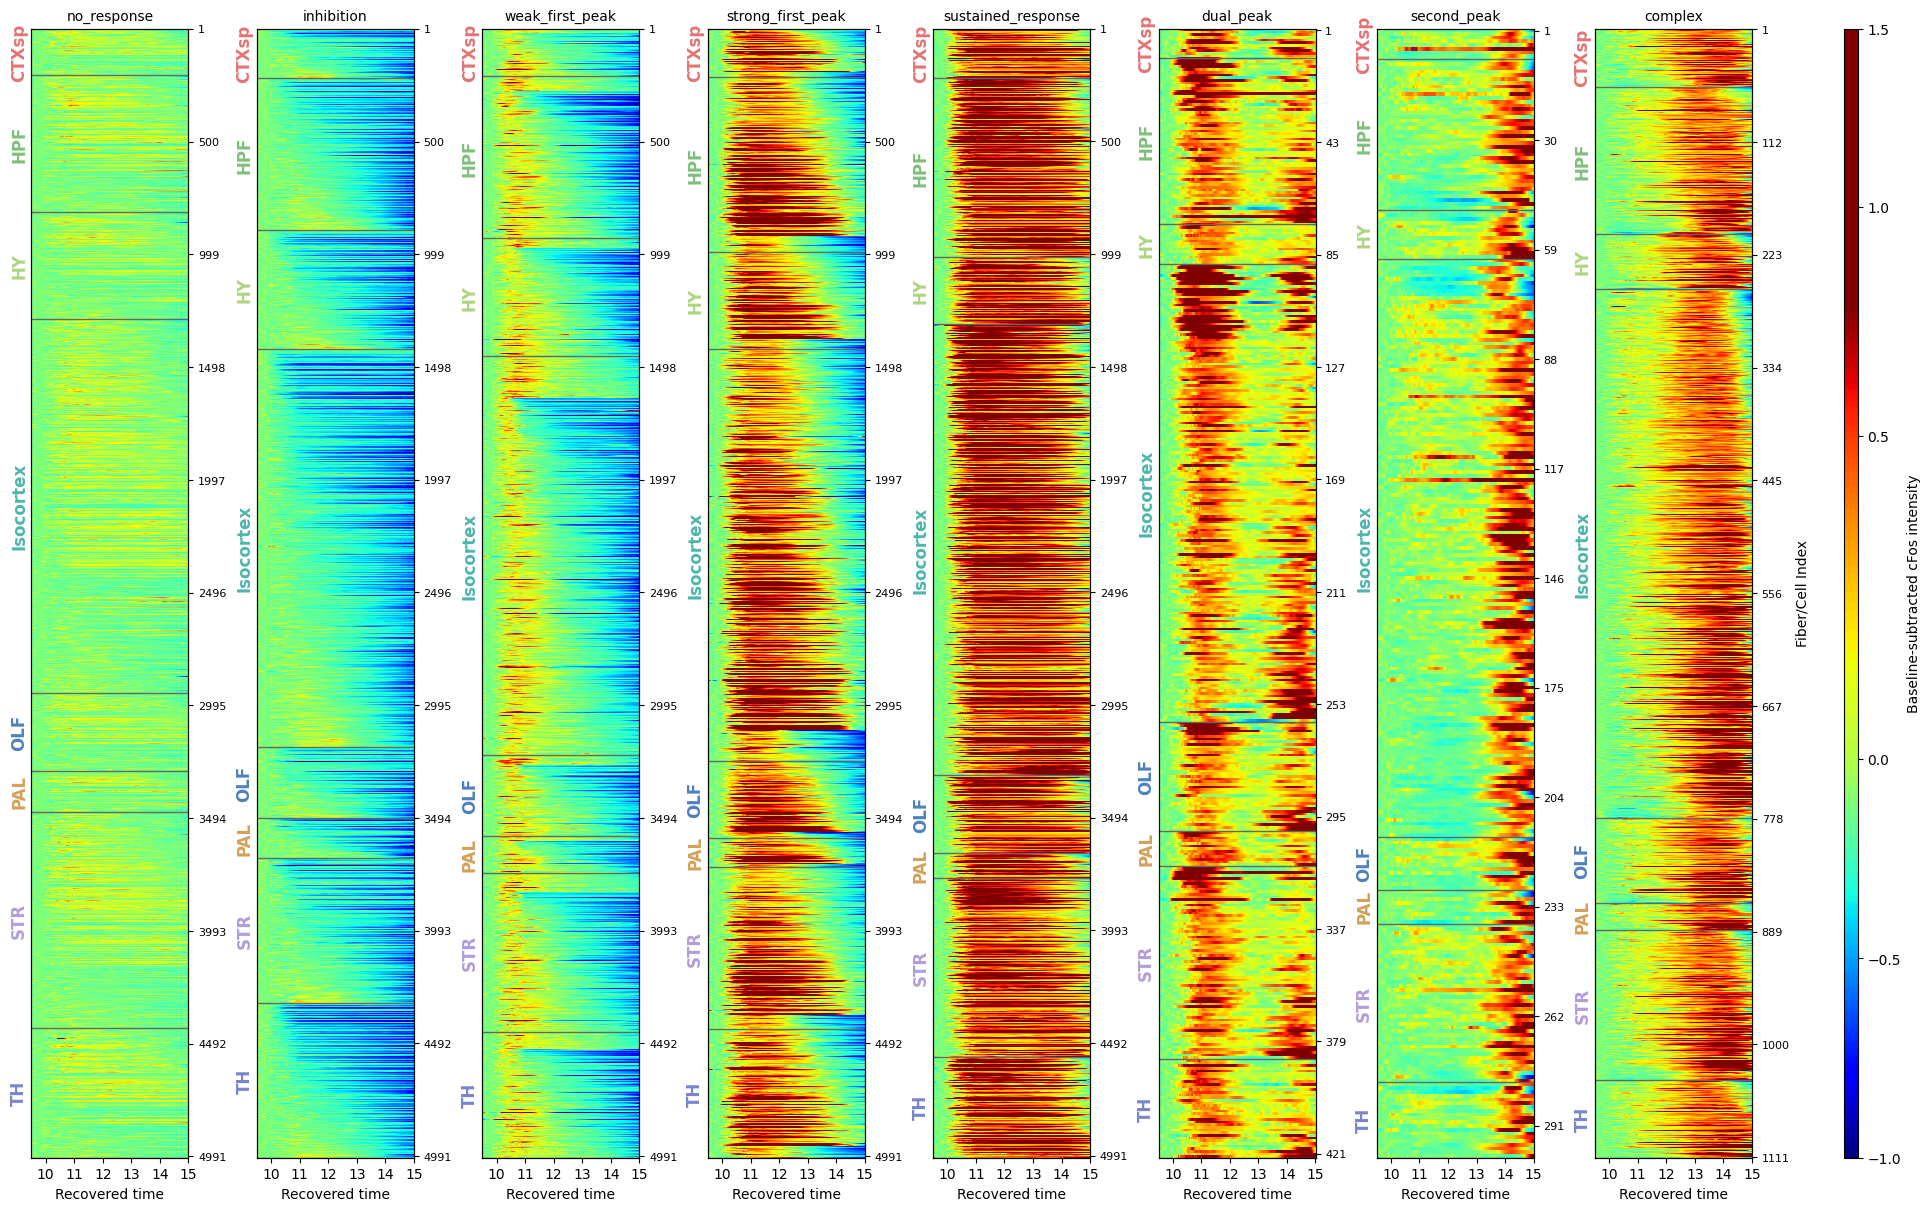

In [7]:
cmap = build_cmap("jet")
norm = build_norm("custom", vmin=-1, vmax=1.5)

fig, axes = plt.subplots(1, len(names), figsize=(2.4 * len(names), 12), constrained_layout=True)
if len(names) == 1:
    axes = [axes]
fig.subplots_adjust(right=0.92, wspace=0.3)

for i, cls_name in enumerate(names):
    heatmap = heatmaps[cls_name]
    boundary = boundaries[cls_name]
    ax = axes[i]
    im = ax.imshow(heatmap, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
    ax.set_title(cls_name, fontsize=10)
    ax.set_xlabel("Recovered time")
    ax.set_xticks([90, 272, 454, 636, 818, 999])
    ax.set_xticklabels(["10", "11", "12", "13", "14", "15"])
    ax.set_yticks([])

    for area_name, start, end in boundary:
        mid = (start + end) / 2
        color = MAJOR_GROUP_COLORS.get(area_name, "#444444")
        ax.text(-80, mid, area_name, rotation=90, va="center", ha="center",
                fontsize=12, fontweight="bold", color=color, clip_on=False)
        ax.hlines(end + 0.5, -0.5, heatmap.shape[1] - 0.5, colors="#666666", linewidth=1.0)

    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim())
    if heatmap.shape[0] > 0:
        idx_ticks = list(range(0, heatmap.shape[0], max(1, heatmap.shape[0] // 10)))
        if idx_ticks[-1] < heatmap.shape[0] - heatmap.shape[0] // 20:
            idx_ticks.append(heatmap.shape[0] - 1)
        ax2.set_yticks(idx_ticks)
        ax2.set_yticklabels([str(i + 1) for i in idx_ticks], fontsize=8)
    if i == len(names) - 1:
        ax2.set_ylabel("Fiber/Cell Index")

cb = fig.colorbar(im, ax=axes, location="right", fraction=0.03, pad=0.02, aspect=80)
cb.set_label("Baseline-subtracted cFos intensity")
plt.savefig(BUNDLE_DIR / "heatmaps_preview.pdf")
plt.show()
